#**Clasification and captioning Aircraft Damage using Pretrained models**

##Introduction
The aim of this project is to classify aircraft damage using a pre-trained VGG16 model and generate captions using a Transformer-based pretrained model.

##Project Overview
Aircraft damage detection is essential for maintaining the safety and longevity of aircraft. Traditional manual inspection methods are time-consuming and prone to human error. This project aims to automate the classification of aircraft damage into two categories: "dent" and "crack." To accomplish this task, feature extraction with a pre-trained VGG16 model will be utilized to classify the damage from aircraft images. Additionally, pre-trained Transformer model will be utilied to generate captions and summaries for the images.

##Aim of the Project
The goal of this project is to develop an automated model that accurately classifies aircraft damage from images.The process will involve training and evaluating a model that utilizes feature extraction from VGG16 for damage classification. This model will be applicable in real-world damage detection within the aviation industry. Furthermore, the project will showcase how we can use a Transformer-based model to caption and summarize images, providing a detailed description of the damage.

##Final Output
*   A trained model capable of classifying aircraft images into "dent" and "crack" categories, enabling automated aircraft damage detection.
*   A Transformer-based model that generates captions and summaries of images

##Datasets
The Aircraft dataset will be used for this project. The dataset is taken from the here ([Original Source](https://universe.roboflow.com/youssef-donia-fhktl/aircraft-damage-detection-1j9qk)): Roboflow Aircraft Dataset Provided by a Roboflow user, License: CC BY 4.

## Table of Contents
### Part 1 - Classification Problem: Classifying the defect on the aircraft as '*dent*' or '*crack*'
1.  1.1 Dataset Preparation
2.  1.2 Data Preprocessing
3.  1.3 Model Definition
4.  1.4 Model Training
5.  1.5 Visualizing Training Results
6.  1.6 Model Evaluation
7.  1.7 Visualizing Predictions

### Part 2: Image Captioning and Summarization using BLIP Pretrained Model
1.  2.1 Loading BLIP Model
2.  2.2 Generating Captions and Summaries

# Setup and required libraries

In [1]:
#  Install required libraries
!pip install pandas
!pip install tensorflow
!pip install pillow
!pip install matplotlib
!pip install transformers
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# Import libraries
import os
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import zipfile
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image
import random

In [3]:
# Set seeds for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# 1. Classification problem: Aircraft defect classification

## Data preparation

In [4]:
## Need Constants
batch_size = 32
n_epochs = 10
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

In [37]:
# Dataset dowload and extraction
## needed libraries dowload and extraction
import tarfile
import urllib.request
import shutil

## Data URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar"

## The path to save the file
file_name = "aircraft_damage_dataset.tar"
extracted_folder = "aircraft_damage_dataset_v1" # Folder where data will be extracted

## Downloading data from data URL using 'urllib.request'
urllib.request.urlretrieve(url, file_name)
print(f"Dowloaded {file_name}. Initiating extraction process")

## Check if the folder already exist
if os.path.exists(extracted_folder):
  print(f"The folder '{extracted_folder}' already exists. Removing the existing folder.")

  # Remove the existing folder
  shutil.rmtree(extracted_folder)
  print(f"Folder '{extracted_folder}' removed successfuly")

## Extract the ziped 'tar' file
with tarfile.open(file_name, "r") as tar_ref:
  tar_ref.extractall()
  print(f"The {file_name} extraction successful completed")


Dowloaded aircraft_damage_dataset.tar. Initiating extraction process
The folder 'aircraft_damage_dataset_v1' already exists. Removing the existing folder.
Folder 'aircraft_damage_dataset_v1' removed successfuly
The aircraft_damage_dataset.tar extraction successful completed


#### Folder structure for Deep Learning datasets
Dataset will be divided into three groups


*   Traing data
*   Validation data
*   Test data
The folder will like
```python
aircraft_damage_dataset_v1/
├── train/
│   ├── dent/
│   └── crack/
├── valid/
│   ├── dent/
│   └── crack/
└── test/
        ├── dent/
        └── crack/
```



In [6]:
# File directories for train, validation and test split
data_folder = "aircraft_damage_dataset_v1"
train_dir = os.path.join(data_folder, "train")
valid_dir = os.path.join(data_folder, "valid")
test_dir = os.path.join(data_folder, "test")

### Data preprocessing
*   Training generator
*   Validation generator
*   Testing generator

In [7]:
# ImageDataGenerators for preprocessing data
train_datagen = ImageDataGenerator(rescale = 1./255)
valid_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [8]:
# Data generator using 'flow_from_directory()' object

### Training generator
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,
    target_size = (img_rows, img_cols),
    batch_size = batch_size,
    seed = seed_value,
    class_mode = 'binary',
    shuffle = True  # Binary classification: dent vs crack
)

### Validation generator
valid_generator = valid_datagen.flow_from_directory(
    directory = valid_dir,
    target_size = (img_rows, img_cols),
    batch_size = batch_size,
    class_mode = 'binary',
    seed = seed_value,
    shuffle = False
)

### Test generator
test_generator = test_datagen.flow_from_directory(
    directory = test_dir,
    target_size = (img_rows, img_cols),
    batch_size = batch_size,
    class_mode = 'binary',
    seed = seed_value,
    shuffle = False
)

Found 300 images belonging to 2 classes.
Found 96 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


## Model definition
*  Defining model model architecture by using pre-trained VGG16 model
*  Adding custom layers on to top for binary classification

In [9]:
# Loading pre-trained VGG16 base model
base_model = VGG16(weights = 'imagenet', include_top = False, input_shape = (img_rows, img_cols, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Base model modification
*  Extract the output from last layer
*  Freezing the be base mode layers that the weights are not updated during traini on new data

In [10]:
output = base_model.layers[-1].output
output = keras.layers.Flatten()(output)
base_model = Model(base_model.input, output)

# Freezing the base Vgg16 model layers
for layer in base_model.layers:
  layer.trainable = False

### Base model fine tuning
*   Adding fully connected layers (Dense)
*   Activation function (ReLU)
*   Dropout layers to avoid overfitting

In [11]:
# Custom model definition
model = Sequential()
model.add(base_model)
## adding two dense layer and one for probability generation
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation = 'sigmoid'))

# Compiling the model
model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

## Model Training

In [12]:
# Model training
history = model.fit(
    train_generator,
    epochs = n_epochs,
    validation_data = valid_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 271s 28s/step - accuracy: 0.5192 - loss: 0.7190 - val_accuracy: 0.6042 - val_loss: 0.6338
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 249s 25s/step - accuracy: 0.7010 - loss: 0.5582 - val_accuracy: 0.6979 - val_loss: 0.5821
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 311s 32s/step - accuracy: 0.7865 - loss: 0.4846 - val_accuracy: 0.7188 - val_loss: 0.5486
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 292s 30s/step - accuracy: 0.8258 - loss: 0.3879 - val_accuracy: 0.6562 - val_loss: 0.6457
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 274s 28s/step - accuracy: 0.8663 - loss: 0.3421 - val_accuracy: 0.7083 - val_loss: 0.5098
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 329s 29s/step - accuracy: 0.8615 - loss: 0.3187 - val_accuracy: 0.7604 - val_loss: 0.4635
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 264s 27s/step - accuracy: 0.9393 - loss: 0.2130 - val_accuracy: 0.7604 - val_loss: 0.4456
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 293s 30s/step - accuracy: 0.9433 - loss: 0.1868 - val_accuracy: 0.

### Training results visualization
*   Training loss
*   Validation loss

In [13]:
train_history = model.history.history

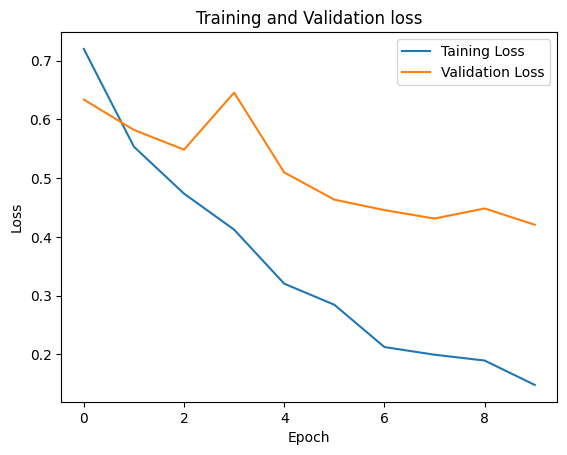

In [14]:
# Plotting train and validation loss
figsize = (10, 7)
plt.title('Training and Validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.plot(train_history['loss'], label = 'Taining Loss')
plt.plot(train_history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

### Accoracy curve for training and validation sets
*  Training accuracy
*  Validation accuracy

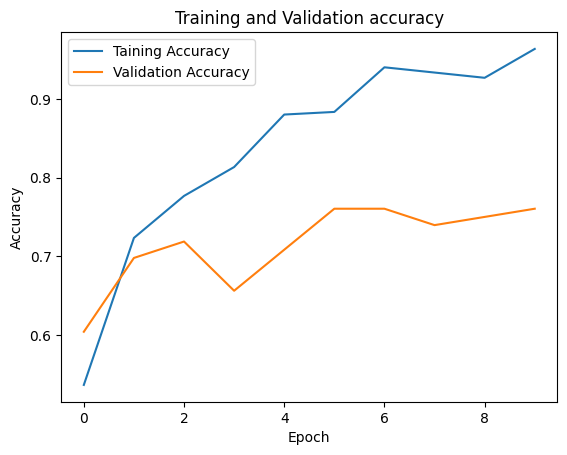

In [15]:
# Training and validation accuracy curves
figsize = (8, 5)
plt.title('Training and Validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.plot(train_history['accuracy'], label = 'Taining Accuracy')
plt.plot(train_history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()
plt.show()

### Visualizing predictions

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Visualization function
## Plot a single image and its prediction
def plot_image_with_title(image, model, true_label, predicted_label, class_names):
  plt.figure(figsize = (6, 6))
  plt.imshow(image)

  ### Labels
  true_label_name = class_names[true_label]
  pred_label_name = class_names[predicted_label]

  print(f"True: {true_label_name}\n Predicted: {pred_label_name}")
  plt.axis('off')
  plt.show()

#Testing model on image
def test_model_on_image(test_generator, model, index_to_plot = 0):
  ## Batch images and labels from the test generator
  test_images, test_labels = next(test_generator)

  ## Predict
  predictions = model.predict(test_images)

  ## Convert prediction from probabilities to binary valuse
  predicted_classes = (predictions > 0.5).astype(int).flatten()

  ## Class indices from tets generator to class names
  class_indices = test_generator.class_indices
  class_names = {v: k for k, v in class_indices.items()}

  ## Image to display based on the index
  image_to_plot = test_images[index_to_plot]
  true_label = test_labels[index_to_plot]
  predicted_label = predicted_classes[index_to_plot]

  ## Ploting the selected image with its true and predicted labels
  plot_image_with_title(image = image_to_plot, model = model, true_label = true_label, predicted_label = predicted_label, class_names = class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
True: dent
 Predicted: dent


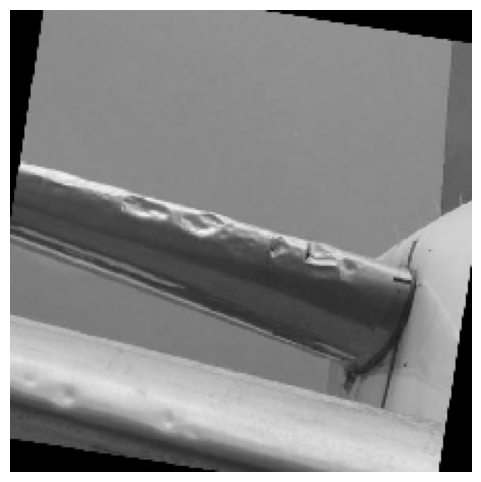

In [23]:
test_model_on_image(test_generator, model, index_to_plot = 16)

# **2 Image captioning and Summarization using BLIP pretrained model**

In [24]:
# Required library
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

In [25]:
# Loading BLIP model and Processor from Hugging Face
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [40]:
# Custom Keras layer - BlipCaptionSummaryLayer
class BlipCaptionSummaryLayer(tf.keras.layers.Layer):
  def __init__(self, processor, model, **kwargs):
    """
     Custom Keras layer wit BLIP processor and Model

     Args:
        processor: BLIP processor for preparing inputs for the model
        model: BLIP model for generating captions and summary.

    """
    super().__init__(**kwargs)
    self.processor = processor
    self.model = model

  def call(self, image_path, task):
    """
    Image loading, preprocessing, and text generation

    Args:
        image_path: Path to the image file as string.
        task: The type of task (Caprion or Summary)

    returns:
        The generated caption and summary as a string.
    """
    try:
      # Decode the image path from Tensorflow tensor to python string
      image_path_str = image_path.numpy().decode("utf-8")

      # Open the image using PIL and convert to RGB format
      image = Image.open(image_path_str).convert("RGB")

      # Prompt for caption or summarization
      if task.numpy().decode("utf-8") == "caption":
        prompt = "This is a picture of"
      else:
        prompt = "This is a detailed photo showing"

      # Input for BLIP model
      inputs = self.processor(images = image, text = prompt, return_tensors = "pt")

      # Text output
      output = self.model.generate(**inputs)

      # Decode the output into a readable string
      result = self.processor.decode(output[0], skip_special_tokens = True)
      return result

    except Exception as e:
      print(f"Error: {e}")
      return 'Error processing image'


In [41]:
# Helper function for using Custom keras layer
def generate_text(image_path, task):
  blip_layer = BlipCaptionSummaryLayer(processor, model)
  return blip_layer(image_path, task)

In [42]:
# Generate caption and summary
# Path to an example image
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")  # actual path of image

# Generate a caption for the image
caption = generate_text(image_path, tf.constant("caption"))
# Decode and print the generated caption
print("Caption:", caption.numpy().decode("utf-8"))

# Generate a summary for the image
summary = generate_text(image_path, tf.constant("summary"))
# Decode and print the generated summary
print("Summary:", summary.numpy().decode("utf-8"))

AttributeError: 'str' object has no attribute 'numpy'

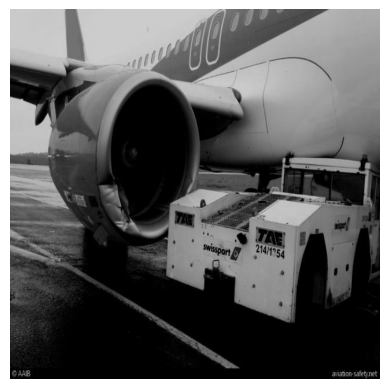

AttributeError: 'str' object has no attribute 'numpy'

In [39]:
image_url1 = "aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg"
image_path1 = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")
# Load and display the image
img = plt.imread(image_url1)
plt.imshow(img)
plt.axis('off')  # Hide the axis
plt.show()
# Generate a caption for the image
caption = generate_text(image_path1, tf.constant("caption"))
# Decode and print the generated caption
print("Caption:", caption.numpy().decode("utf-8"))

# Generate a summary for the image
summary = generate_text(image_path1, tf.constant("summary"))
# Decode and print the generated summary
print("Summary:", summary.numpy().decode("utf-8"))